<a href="https://colab.research.google.com/github/utamiu1807/uutami/blob/main/Another_copy_of_ML_Foundations_Starter_Code_for_Clustering_Credit_Card_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
# Must be installed the first time you run this code
!pip install hdbscan
!pip install kneed

In [58]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px
from google.colab import drive
from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

from kneed import KneeLocator
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
import hdbscan

In [35]:
# Load an CSV file
file_path = 'https://www.dropbox.com/scl/fi/1jml6i3whezn5dzarkb6a/credit_card_customers.csv?rlkey=o5yjpunceaa9vo51yyudn0qw8&st=6tcl8ivy&dl=1'
data = pd.read_csv(file_path)

data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## Data Exploration

In [36]:
# Drop ID and outcome variable for clustering EDA
df_eda = data.drop(columns=["CLIENTNUM", "Attrition_Flag"], errors="ignore")

# Numeric vs categorical
num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df_eda.columns if c not in num_cols]

print("Numeric columns:", len(num_cols))
print(num_cols)
print("\nCategorical columns:", len(cat_cols))
print(cat_cols)

#check any missing value
df_eda.isna().any().any()

#statistic
num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()

df_eda[num_cols].describe().T

Numeric columns: 14
['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

Categorical columns: 5
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000,46.000,52.000,73.000
Dependent_count,10127.0,2.346203,1.298908,0.0,1.000,2.000,3.000,5.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
Total_Amt_Chng_Q4_Q1,10127.0,0.759941,0.219207,0.0,0.631,0.736,0.859,3.397


In [37]:
#relationship on card category to their spending behaviour
card_order = ["Blue", "Silver", "Gold", "Platinum"]
key_numeric = [
    "Avg_Utilization_Ratio",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Revolving_Bal",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Ct_Chng_Q4_Q1",
]

key_numeric = [c for c in key_numeric if c in df_eda.columns]

# Convert 'Card_Category' to a Categorical type with the specified order
df_eda['Card_Category'] = pd.Categorical(df_eda['Card_Category'], categories=card_order, ordered=True)

df_eda.groupby("Card_Category")[key_numeric].mean().round(2)

/tmp/ipython-input-765911596.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eda.groupby("Card_Category")[key_numeric].mean().round(2)


,Avg_Utilization_Ratio,Total_Trans_Amt,Total_Trans_Ct,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Ct_Chng_Q4_Q1
Card_Category,,,,,,
Blue,0.29,4225.41,64.03,1157.81,0.76,0.71
Silver,0.06,6590.48,74.70,1206.13,0.76,0.71
Gold,0.06,7685.61,81.52,1344.32,0.77,0.71
Platinum,0.04,8999.75,86.95,1267.95,0.78,0.67


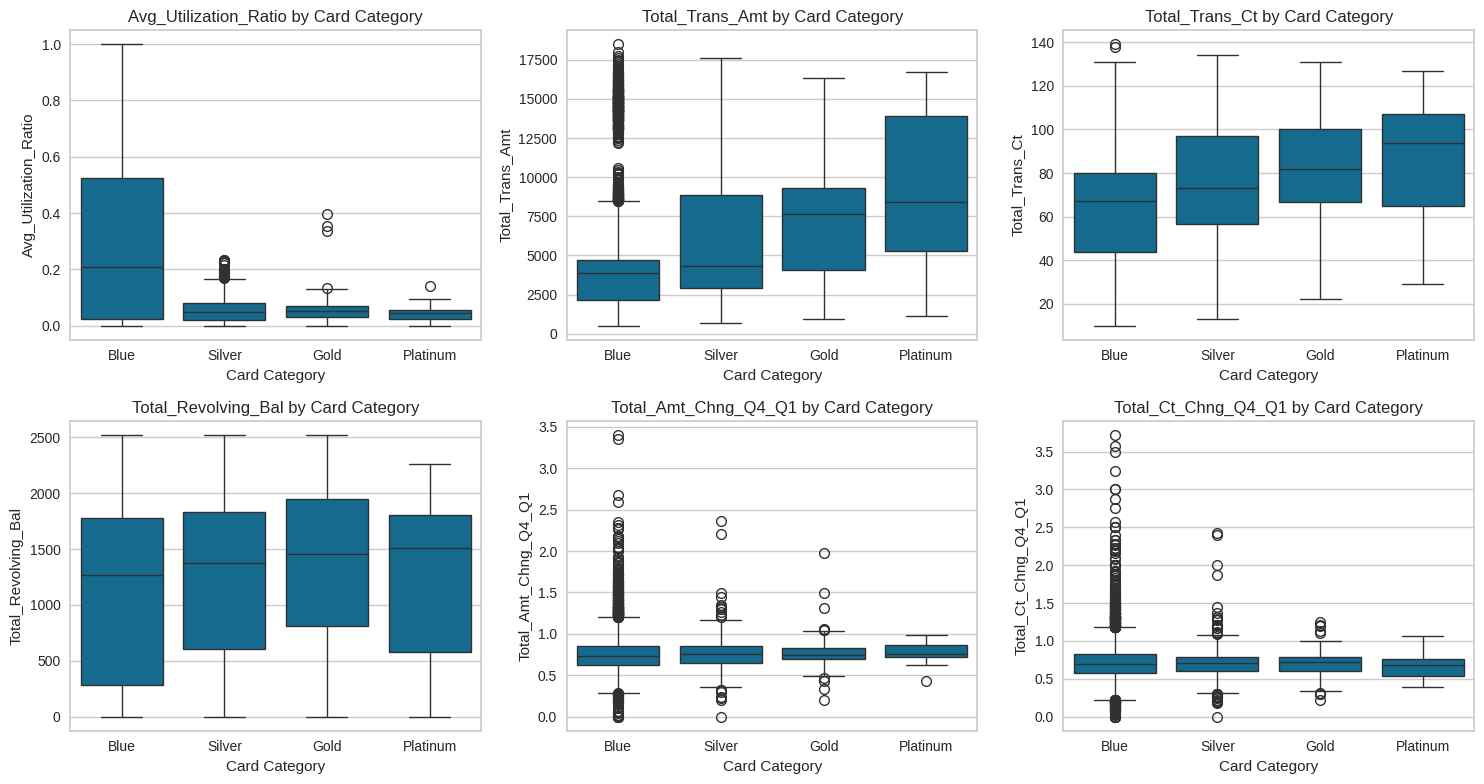

In [38]:
n_cols = 3                      # how many plots per row
n_rows = math.ceil(len(key_numeric) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    sns.boxplot(
        x="Card_Category",
        y=col,
        data=df_eda,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} by Card Category")
    axes[i].set_xlabel("Card Category")
    axes[i].set_ylabel(col)

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




This EDA indicates some card category overlapping and outlier

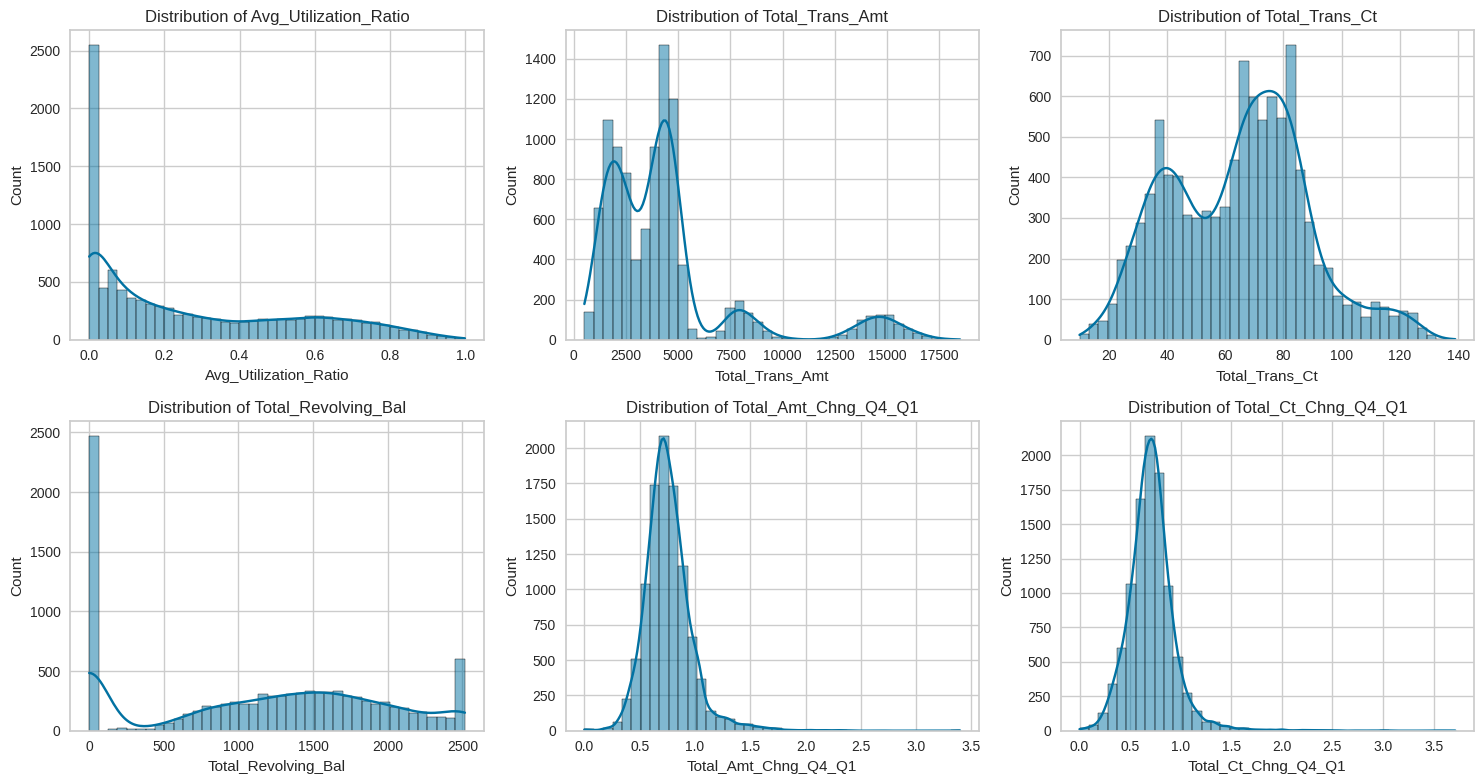

In [39]:
# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    sns.histplot(df_eda[col], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [40]:
#Analysis based on revenue driver
#Average utilization ratio is left skewed, meaning to increase transaction-based fee,

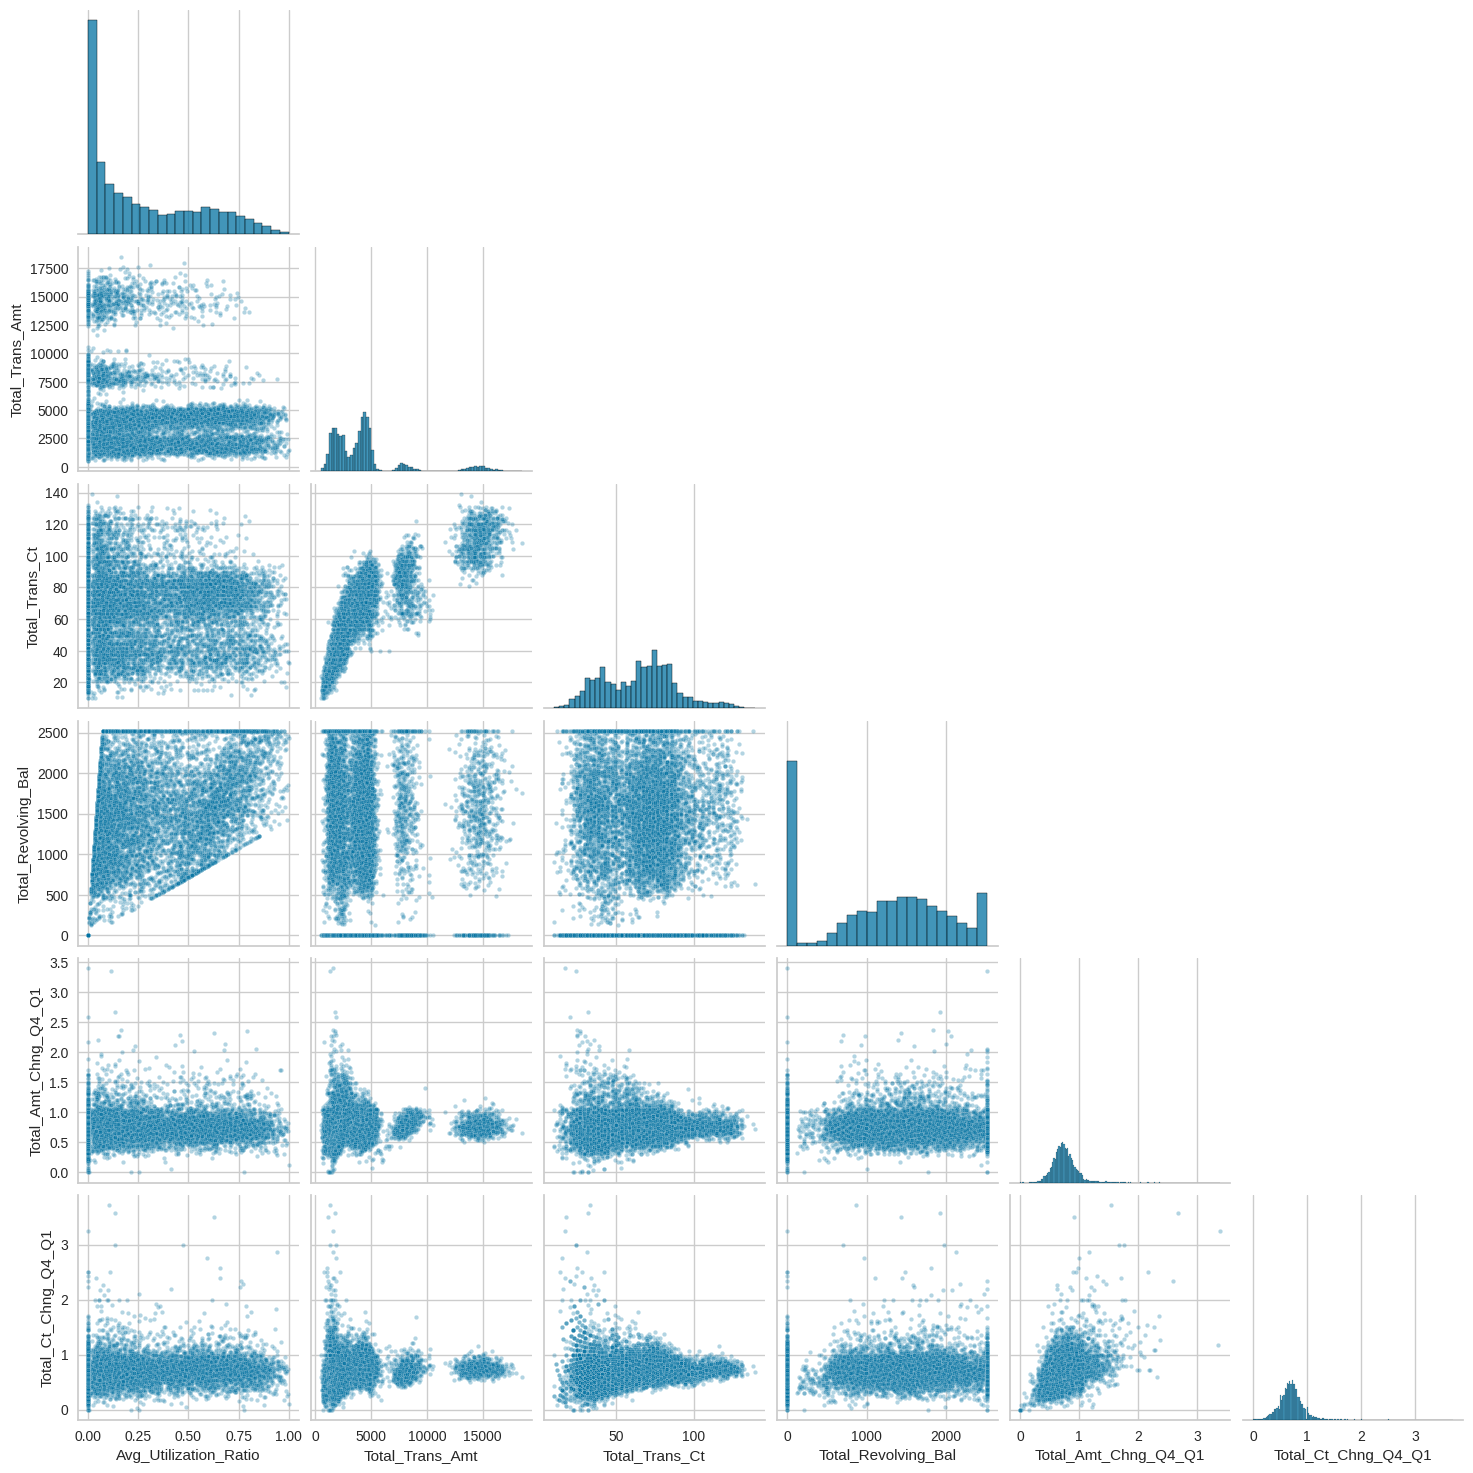

In [41]:
sns.pairplot(
    df_eda[key_numeric],
    corner=True,
    plot_kws={"alpha": 0.3, "s": 10}
)
plt.show()


#Analysis on Behaviour compared to the revenue driver:
1. Credit Utilization Behaviour & Interest Potential
Key feature : avg_utilization ratio & revolving balance
The plots comparing Revolving balance vs Average Utilization Ratio exhibits a clear triangular or wedge-shaped structure rather than a linear trend. Rrevolving balances are bounded by a customer’s credit limit and therefore increase mechanically with utilization. Customers with high utilization ratios are operating close to their credit limits and are more likely to carry persistent balances, generating interest revenue but also indicating elevated financial stress.

2. Spending Behaviour
Key Feature ;
a) Total_trans_amt & Total_trans_ct --> signalling 3 clusters
b) Revolving balance & Total trans_amt --> the figure shows vertical bands and substantial dispersion, indicating that customers with similar transaction volumes can have very different revolving balances. Many customers with high transaction amounts carry little or no revolving balance, while others accumulate substantial balances despite moderate transaction activity.



# A**nalysis on Engagement & Relationship Behaviour**


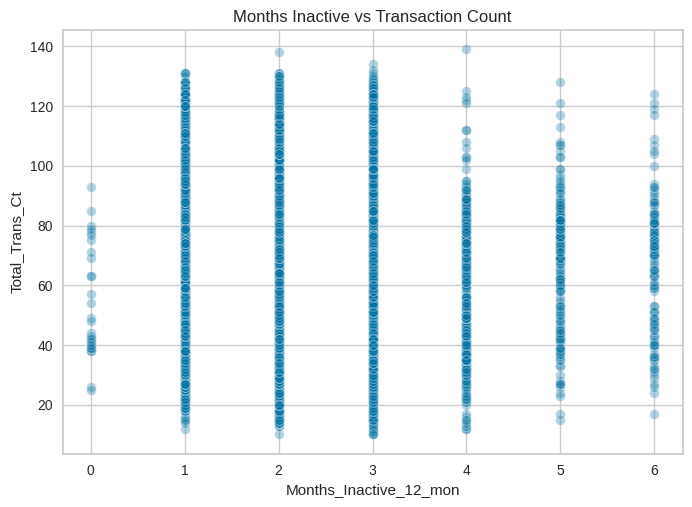

In [42]:
if "Months_Inactive_12_mon" in df_eda.columns:
    plt.figure()
    sns.scatterplot(x=df_eda["Months_Inactive_12_mon"], y=df_eda["Total_Trans_Ct"], alpha=0.3)
    plt.title("Months Inactive vs Transaction Count")
    plt.xlabel("Months_Inactive_12_mon")
    plt.ylabel("Total_Trans_Ct")
    plt.show()


There is a clear negative association
As months inactive increase, the typical transaction count decreases.

“The scatterplot of months inactive versus transaction count shows a clear decline in transaction activity as inactivity increases, with substantial heterogeneity within each inactivity level.

There is also Ratio called: "Contact-to-Inactivity Ratio": Contacts_ct_12_mon/ months_inactive_12_mon.

## Data Preprocesssing

In [43]:
# ---- Engineer avg transaction value safely ----
# avg_transaction_value = Total_Trans_Amt / Total_Trans_Ct
# Handle Total_Trans_Ct == 0 to avoid division by zero
df=df_eda.copy()
df["avg_transaction_value"] = np.where(
    df["Total_Trans_Ct"] == 0,
    0,
    df["Total_Trans_Amt"] / df["Total_Trans_Ct"]
)

features = [
    "Total_Revolving_Bal",
    "Avg_Utilization_Ratio",
    "avg_transaction_value"
]

X = df[features].copy()

# ---- Basic cleaning ----
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# ---- Scale (critical for K-Means) ----
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

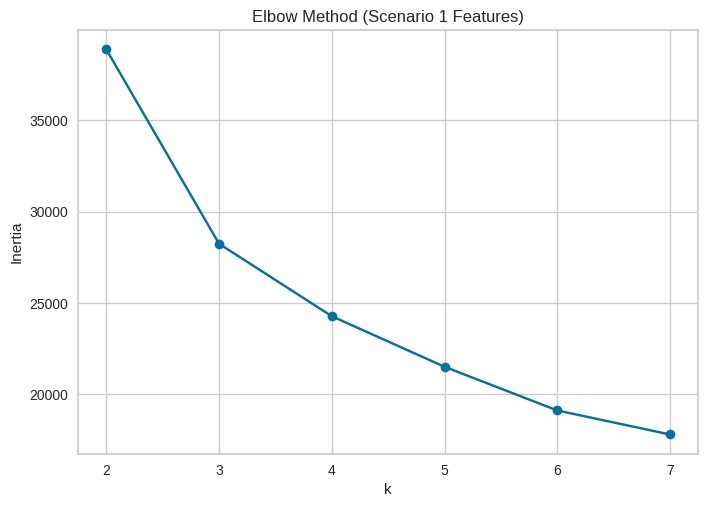

In [52]:
from sklearn.cluster import KMeans

inertias = []
ks = range(2, 8)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(Xs)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(ks, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method (Scenario 1 Features)")
plt.show()


THE Elbow method is still unclear to use the number of k

In [44]:
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init="auto")
labels = kmeans.fit_predict(Xs)

sil = silhouette_score(Xs, labels)
print("Silhouette (full data):", round(sil, 4))


Silhouette (full data): 0.4336


In [45]:
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init="auto")
labels = kmeans.fit_predict(Xs)

sil = silhouette_score(Xs, labels)
print("Silhouette (full data):", round(sil, 4))


Silhouette (full data): 0.4293


In [46]:
def stability_across_seeds(Xs, k=3, seeds=range(40, 60)):
    labels_list = []
    sil_list = []

    for s in seeds:
        km = KMeans(n_clusters=k, random_state=s, n_init="auto")
        labels = km.fit_predict(Xs)
        labels_list.append(labels)
        sil_list.append(silhouette_score(Xs, labels))

    # Pairwise ARI between consecutive runs
    ari_consecutive = [
        adjusted_rand_score(labels_list[i], labels_list[i+1])
        for i in range(len(labels_list)-1)
    ]

    return pd.DataFrame({
        "seed_start": list(seeds)[:-1],
        "seed_next": list(seeds)[1:],
        "ARI_consecutive": ari_consecutive,
        "silhouette_seed_next": sil_list[1:]
    })

seed_stability = stability_across_seeds(Xs, k=k_final)
seed_stability.describe()


,seed_start,seed_next,ARI_consecutive,silhouette_seed_next
count,19.000000,19.000000,19.000000,19.000000
mean,49.000000,50.000000,0.932688,0.428330
std,5.627314,5.627314,0.173722,0.002625
min,40.000000,41.000000,0.437924,0.417533
25%,44.500000,45.500000,0.986901,0.428686
50%,49.000000,50.000000,0.987893,0.428824
75%,53.500000,54.500000,0.993269,0.429139
max,58.000000,59.000000,1.000000,0.429255


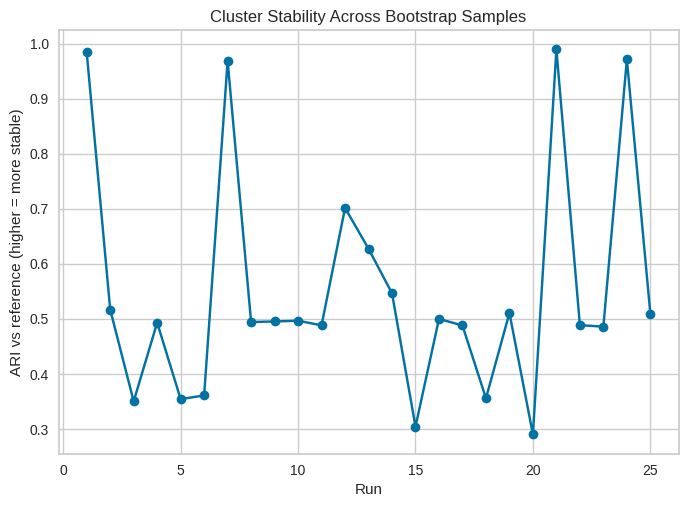

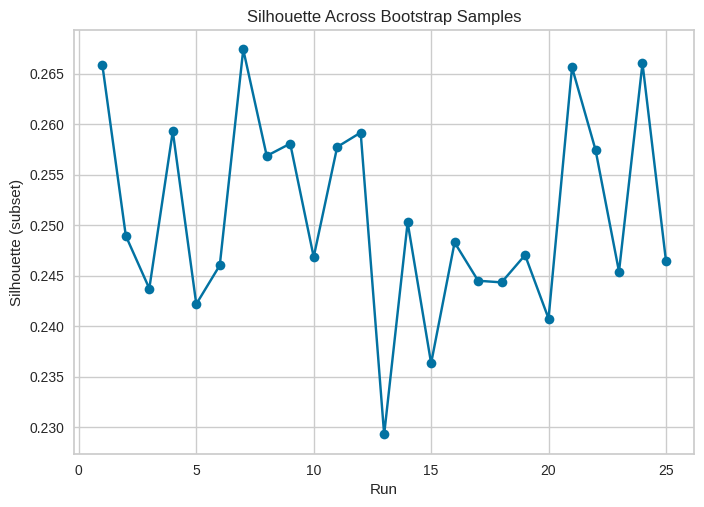

In [51]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(stability_df["run"], stability_df["ARI_vs_reference"], marker="o")
plt.xlabel("Run")
plt.ylabel("ARI vs reference (higher = more stable)")
plt.title("Cluster Stability Across Bootstrap Samples")
plt.show()

plt.figure()
plt.plot(stability_df["run"], stability_df["silhouette_subset"], marker="o")
plt.xlabel("Run")
plt.ylabel("Silhouette (subset)")
plt.title("Silhouette Across Bootstrap Samples")
plt.show()


===== FULL-DATA SILHOUETTE =====
Baseline silhouette (k=3): 0.4336
With growth vars silhouette (k=3): 0.2815

===== STABILITY SUMMARY (ARI) =====
Baseline ARI_consecutive describe:
count    19.000000
mean      0.983353
std       0.015677
min       0.963856
25%       0.967430
50%       0.994107
75%       0.998255
max       1.000000
Name: ARI_consecutive, dtype: float64

With Growth Vars ARI_consecutive describe:
count    19.000000
mean      0.890388
std       0.207136
min       0.496036
25%       0.983486
50%       0.992766
75%       0.998737
max       1.000000
Name: ARI_consecutive, dtype: float64

===== CLUSTER PROFILES (MEANS + COUNTS) =====

Baseline profile:
         Total_Revolving_Bal  Avg_Utilization_Ratio  avg_transaction_value  \
cluster                                                                      
0                  1729.5931                 0.4896                54.2810   
1                   441.5449                 0.0552                54.2829   
2                

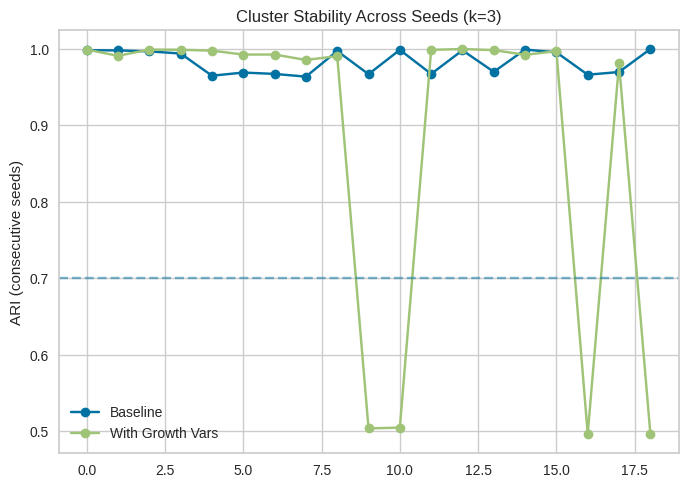

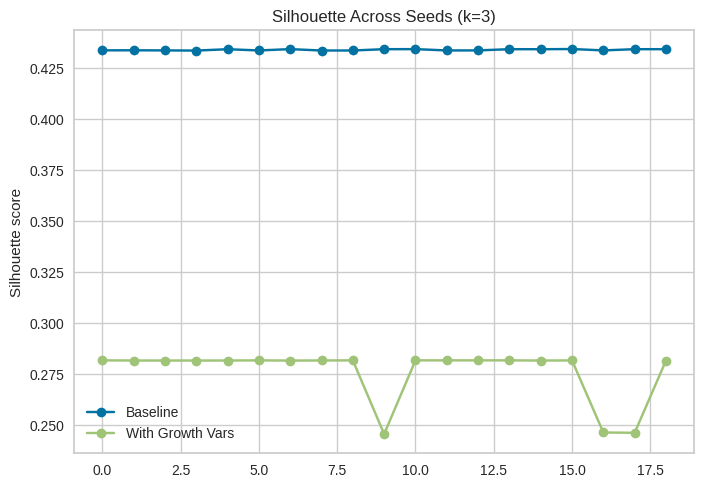

In [64]:
#stability test by adding more variable
# COMPLETE PIPELINE: Engineer features, add growth variables, run K-Means, and test stability (ARI + Silhouette)
# Scenario: Compare stability of:
#   (A) Baseline Scenario 1 features
#   (B) Baseline + "Total_Amt_Chng_Q4_Q1" and "Total_Ct_Chng_Q4_Q1"


# -----------------------------
# 3) Define feature sets
# -----------------------------
features_base = [
    "Total_Revolving_Bal",
    "Avg_Utilization_Ratio",
    "avg_transaction_value"
]

features_growth = [
    "Total_Revolving_Bal",
    "Avg_Utilization_Ratio",
    "avg_transaction_value",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Ct_Chng_Q4_Q1"
]

# -----------------------------
# 4) Helper functions
# -----------------------------
def preprocess_features(df_in, features):
    """
    Select features, clean inf/nan, impute with median, and standardize.
    Returns standardized numpy array Xs.
    """
    X = df_in[features].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))
    Xs = StandardScaler().fit_transform(X)
    return Xs

def stability_across_seeds(Xs, k=3, seeds=range(40, 60)):
    """
    Fit KMeans repeatedly with different random_state seeds.
    Returns a DataFrame with:
      - ARI between consecutive runs (stability)
      - silhouette scores per run (quality consistency)
    """
    labels_list = []
    sil_list = []

    for s in seeds:
        km = KMeans(n_clusters=k, random_state=s, n_init="auto")
        labels = km.fit_predict(Xs)
        labels_list.append(labels)
        sil_list.append(silhouette_score(Xs, labels))

    ari_consecutive = [
        adjusted_rand_score(labels_list[i], labels_list[i + 1])
        for i in range(len(labels_list) - 1)
    ]

    # align silhouettes to same length as ARI (drop first)
    return pd.DataFrame({
        "seed_start": list(seeds)[:-1],
        "seed_next": list(seeds)[1:],
        "ARI_consecutive": ari_consecutive,
        "silhouette_seed_next": sil_list[1:]
    })

def fit_final_kmeans_and_profile(df_in, Xs, features, k=3, random_state=42):
    """
    Fit final KMeans on full standardized data and return:
      - df_out with cluster labels
      - cluster profile (means + counts)
      - silhouette on full data
    """
    km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    labels = km.fit_predict(Xs)

    df_out = df_in.copy()
    df_out["cluster"] = labels

    profile = df_out.groupby("cluster")[features].mean().round(4)
    profile["count"] = df_out["cluster"].value_counts().sort_index()
    sil = silhouette_score(Xs, labels)

    return df_out, profile, sil

# -----------------------------
# 5) Choose k
# -----------------------------
k_final = 3

# -----------------------------
# 6) Preprocess and test stability (Baseline)
# -----------------------------
Xs_base = preprocess_features(df, features_base)
stability_base = stability_across_seeds(Xs_base, k=k_final, seeds=range(40, 60))

# Fit final model and profile (Baseline)
df_base, profile_base, sil_base = fit_final_kmeans_and_profile(df, Xs_base, features_base, k=k_final)

# -----------------------------
# 7) Preprocess and test stability (With Growth Variables)
# -----------------------------
Xs_growth = preprocess_features(df, features_growth)
stability_growth = stability_across_seeds(Xs_growth, k=k_final, seeds=range(40, 60))

# Fit final model and profile (With Growth Variables)
df_growth, profile_growth, sil_growth = fit_final_kmeans_and_profile(df, Xs_growth, features_growth, k=k_final)

# -----------------------------
# 8) Print summary results
# -----------------------------
print("===== FULL-DATA SILHOUETTE =====")
print(f"Baseline silhouette (k={k_final}): {sil_base:.4f}")
print(f"With growth vars silhouette (k={k_final}): {sil_growth:.4f}")

print("\n===== STABILITY SUMMARY (ARI) =====")
print("Baseline ARI_consecutive describe:")
print(stability_base["ARI_consecutive"].describe())

print("\nWith Growth Vars ARI_consecutive describe:")
print(stability_growth["ARI_consecutive"].describe())

print("\n===== CLUSTER PROFILES (MEANS + COUNTS) =====")
print("\nBaseline profile:")
print(profile_base)

print("\nWith Growth Vars profile:")
print(profile_growth)

# -----------------------------
# 9) Visualize stability (ARI + Silhouette over seed runs)
# -----------------------------
plt.figure()
plt.plot(stability_base["ARI_consecutive"].values, marker="o", label="Baseline")
plt.plot(stability_growth["ARI_consecutive"].values, marker="o", label="With Growth Vars")
plt.axhline(0.7, linestyle="--", alpha=0.5)
plt.ylabel("ARI (consecutive seeds)")
plt.title(f"Cluster Stability Across Seeds (k={k_final})")
plt.legend()
plt.show()

plt.figure()
plt.plot(stability_base["silhouette_seed_next"].values, marker="o", label="Baseline")
plt.plot(stability_growth["silhouette_seed_next"].values, marker="o", label="With Growth Vars")
plt.ylabel("Silhouette score")
plt.title(f"Silhouette Across Seeds (k={k_final})")
plt.legend()
plt.show()


## K-Means Clustering

In [55]:
#prepare fetaures and scaling
features = [
    "Total_Revolving_Bal",
    "Avg_Utilization_Ratio",
    "avg_transaction_value"
]

df_work=df.copy()
X = df_work[features].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

k_final = 3   # change to 4 if you want to test k=4

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init="auto")
df_work["cluster"] = kmeans.fit_predict(Xs)

df_work["cluster"].value_counts().sort_index()


,count
cluster,
0,4839
1,4074
2,1214


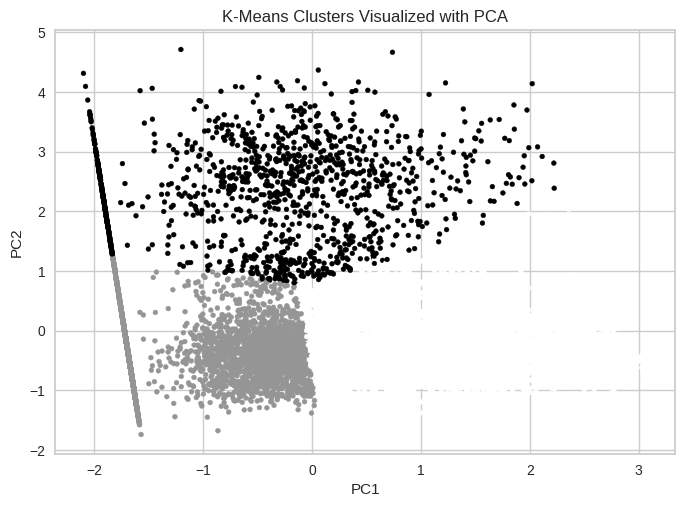

Explained variance ratio (PC1, PC2): [0.54288625 0.33708581]


In [59]:
#pca visualization
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(Xs)

plt.figure()
plt.scatter(Xp[:, 0], Xp[:, 1], c=df_work["cluster"], s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters Visualized with PCA")
plt.show()

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)


In [60]:
cluster_profile = df_work.groupby("cluster")[features].mean().round(3)
cluster_profile["count"] = df_work["cluster"].value_counts().sort_index()
cluster_profile


,Total_Revolving_Bal,Avg_Utilization_Ratio,avg_transaction_value,count
cluster,,,,
0,1729.593,0.490,54.281,4839
1,441.545,0.055,54.283,4074
2,1324.105,0.156,123.777,1214


Card_Category,Blue,Silver,Gold,Platinum
cluster,,,,
0,0.976,0.019,0.004,0.000
1,0.926,0.062,0.010,0.002
2,0.775,0.171,0.045,0.009


Card_Category   Blue  Silver   Gold  Platinum
cluster                                      
0              0.976   0.019  0.004     0.000
1              0.926   0.062  0.010     0.002
2              0.775   0.171  0.045     0.009
Card_Category  Blue  Silver  Gold  Platinum
cluster                                    
0              4724      94    21         0
1              3771     254    40         9
2               941     207    55        11


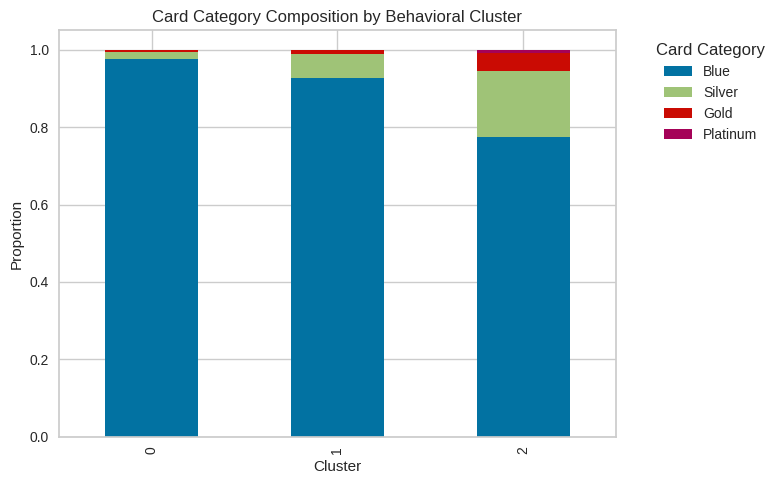

,Total_Revolving_Bal,Avg_Utilization_Ratio,avg_transaction_value,count
cluster,,,,
0,1729.59,0.49,54.28,4839
1,441.54,0.06,54.28,4074
2,1324.10,0.16,123.78,1214


In [75]:
#post-hoc validation: Check the clusters relate to the bank’s existing card categories (Blue, Silver, Gold, Platinum)
cluster_card_pct = pd.crosstab(
    df_work["cluster"],
    df_work["Card_Category"],
    normalize="index"
).round(3)

print(cluster_card_pct)

#cluster counts
cluster_card_counts = pd.crosstab(
    df_work["cluster"],
    df_work["Card_Category"]
)

print(cluster_card_counts)

#visualize
cluster_card_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.ylabel("Proportion")
plt.xlabel("Cluster")
plt.title("Card Category Composition by Behavioral Cluster")
plt.legend(title="Card Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

cluster_profile = (
    df_work
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

cluster_profile["count"] = df_work["cluster"].value_counts().sort_index()
cluster_profile

## Hierarchical Clustering

## DBSCAN

In [49]:
data.to_csv('clustered_data.csv', index=False)
files.download('clustered_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>